In [1]:
import requests

# pip install beautifulsoup4
from bs4 import BeautifulSoup

# https://www.weather.go.kr/ > 관측기후 > 육상 > 도시별관측
response = requests.get("https://www.weather.go.kr/w/obs-climate/land/city-obs.do")
soup = BeautifulSoup(response.content, 'html.parser')

table = soup.find('table', id='weather_table')

table

data = []
for tr in table.find_all('tr'):
    tds = list(tr.find_all('td'))

    for td in tds:
        if td.find('a'):
            point = td.find('a').text
            temperature = tds[5].text
            humidity = tds[10].text

            data.append([point, temperature, humidity])

data
       




[['강릉', '13.6', '58'],
 ['강진군', '11.1', '58'],
 ['강화', '9.2', '61'],
 ['거제', '15.0', '56'],
 ['거창', '13.2', '41'],
 ['경주시', '11.0', '79'],
 ['고산', '14.7', '57'],
 ['고창', '7.9', '44'],
 ['고창군', '8.3', '52'],
 ['고흥', '9.1', '51'],
 ['광양시', '14.4', '38'],
 ['광주', '15.2', '24'],
 ['구미', '17.7', '29'],
 ['군산', '9.3', '59'],
 ['금산', '10.5', '49'],
 ['김해시', '14.1', '45'],
 ['남원', '11.8', '49'],
 ['남해', '13.1', '45'],
 ['대관령', '3.5', '79'],
 ['대구', '15.3', '41'],
 ['대전', '14.7', '30'],
 ['동두천', '13.8', '43'],
 ['동해', '11.0', '84'],
 ['목포', '10.2', '62'],
 ['문경', '13.8', '43'],
 ['밀양', '12.7', '49'],
 ['백령도', '9.7', '47'],
 ['보령', '9.0', '57'],
 ['보성군', '9.5', '65'],
 ['보은', '11.4', '51'],
 ['봉화', '8.4', '65'],
 ['부산', '14.7', '55'],
 ['부안', '8.6', '63'],
 ['부여', '11.9', '50'],
 ['북강릉', '10.1', '74'],
 ['북부산', '12.9', '58'],
 ['북창원', '14.7', '61'],
 ['북춘천', '11.0', '53'],
 ['산청', '14.9', '39'],
 ['상주', '16.5', '33'],
 ['서귀포', '17.7', '25'],
 ['서산', '7.7', '60'],
 ['서울', '14.0', '41'],
 ['성산', '

In [2]:
with open('weather.csv', 'w', encoding='UTF8') as file:
    file.write('point, temperature, humidity\n')
    for i in data:
        file.write(f'{i[0]},{i[1]},{i[2]}\n')

In [3]:
# matplotlib.pyplot의 show 함수를 호출하지 않아도 주피터 노트북 안에서 그래프가 표시됨
# %matplotlib inline
import pandas as pd # 데이터 처리

df = pd.read_csv('weather.csv', index_col='point') # csv 파일을 읽어서 DataFrame 객체로 만듦. 인덱스 항목(컬럼)은 point로 설정
df



,temperature,humidity
point,,
강릉,13.6,58
강진군,11.1,58
강화,9.2,61
거제,15.0,56
거창,13.2,41
...,...,...
합천,12.6,48
해남,7.8,66
홍성,8.1,66


In [4]:
# 특별시, 광역시만 모아서 DataFrame 객체로 만듦
# loc 속성은 label-location의 약자로 레이블을 지정해 특정 인덱스의 데이터만 가져오는데 씀
city_df = df.loc[['서울', '인천', '대전', '대구', '광주', '부산', '울산']]
city_df    # city_df 표시

,temperature,humidity
point,,
서울,14.0,41
인천,9.9,66
대전,14.7,30
대구,15.3,41
광주,15.2,24
부산,14.7,55
울산,12.8,58


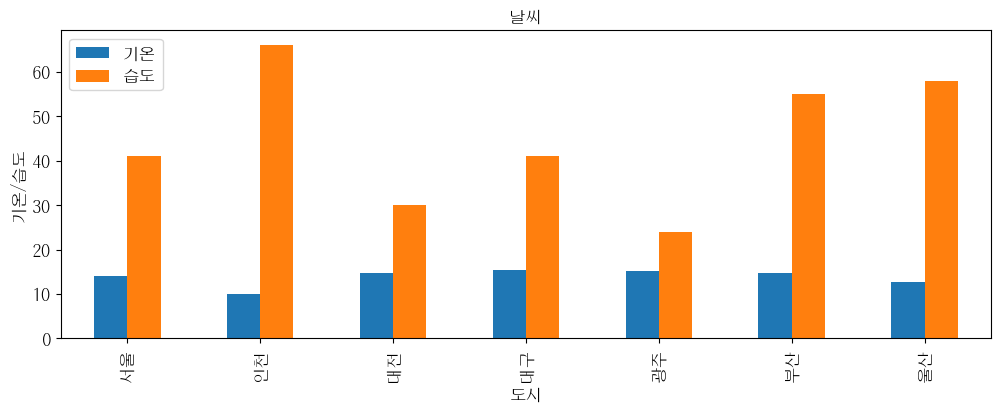

In [11]:
# Windows 한글 폰트 설정
# pip install matplotlib
import matplotlib as mpl

# AttributeError: module 'matplotlib' has no attribute 'font_manager' 에러가 발생하면 해당 코드를 주석 처리한 후 실행한 후, 주석 해제 후 다시 실행하면 됨
font_name = mpl.font_manager.FontProperties(fname='C:/Windows/Fonts/HYGPRM.TTF').get_name()
mpl.rc('font', family=font_name)

# 차트 종류, 제목, 차트 크기, 범례, 폰트 크기 설정
ax = city_df.plot(kind='bar', title='날씨', figsize=(12, 4), legend=True, fontsize=12)
ax.set_xlabel('도시', fontsize=12)          # x축 정보 표시
ax.set_ylabel('기온/습도', fontsize=12)     # y축 정보 표시
ax.legend(['기온', '습도'], fontsize=12)    # 범례 지정

# import matplotlib.pyplot as plt # IDLE, 파이썬 인터프리터에서 그래프 표시
# plt.show()